<a href="https://colab.research.google.com/github/AbeAlsop/CIU-DET-520/blob/main/DET_520_Disaster_Tweets.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Login and download Disaster Tweets
import kagglehub
kagglehub.login()

Kaggle credentials set.
Kaggle credentials successfully validated.


In [ ]:
# Download Disaster Tweets
kaggle_tweet_dir = kagglehub.competition_download('nlp-getting-started')

100%|██████████| 593k/593k [00:00<00:00, 644kB/s]

Extracting files...


In [ ]:
# Create datasets
import pandas as pd
import numpy as np

df_train = pd.read_csv(kaggle_tweet_dir + '/train.csv')
df_test = pd.read_csv(kaggle_tweet_dir + '/test.csv')

# Examine contents of the data
print(f"Training data has {len(df_train)} tweets. Test data has {len(df_test)} tweets.")
print(f"{len(df_train[df_train['target']==1]) * 100.0 / len(df_train):.2f}% of the training tweets relate to disasters.")
print("Columns and data types:")
print(df_train.dtypes)
print(f"Keyword set on {len(df_train[pd.notna(df_train['keyword'])])} rows, {len(df_train['keyword'].unique())} unique values.")
print(f"Location set on {len(df_train[pd.notna(df_train['location'])])} rows, {len(df_train['location'].unique())} unique values.")

Training data has 7613 tweets. Test data has 3263 tweets.
42.97% of the training tweets relate to disasters.
Columns and data types:
id           int64
keyword     object
location    object
text        object
target       int64
dtype: object
Keyword set on 7552 rows, 222 unique values.
Location set on 5080 rows, 3342 unique values.


In [ ]:
# Bag of words

# Find set of unique sanitized words
import re
def sanitize_word(word):
  if word.startswith('http://') or word.startswith('https://'):
    return 'http://'
  if word.startswith('@'):
    return '@'
  if word.startswith('#'):
    return word[1:].lower()
  return re.sub(r"[\[\](),.?!]","",word).lower()

df_bag_train = df_train.copy()
df_bag_train['all_words'] = df_bag_train['keyword'].fillna('') + ' ' + df_bag_train['location'].fillna('') + ' ' + df_bag_train['text']
word_list = ' '.join(df_bag_train['all_words']).split()
word_list = [sanitize_word(word) for word in word_list]
word_set = set(word_list)
print(f"Found {len(word_list)} total words, {len(word_set)} unique words")

# Define encoder functions
word_to_code_dict = {}
for i,w in enumerate(sorted(word_set)):
  word_to_code_dict[w] = i

def encode_word(word):
  word = sanitize_word(word)
  if word not in word_to_code_dict:
    return 0
  return word_to_code_dict[word]+1

def encode_row(row):
  encoded = np.zeros(len(word_to_code_dict)+1, dtype=np.uint8)
  if isinstance(row['keyword'], str):
    encoded[encode_word(row['keyword'])] += 1
  if isinstance(row['location'], str):
    for word in row['location'].split():
      encoded[encode_word(word)] += 1
  for word in row['text'].split():
    encoded[encode_word(word)] += 1
  return encoded

Found 131862 total words, 19676 unique words


In [ ]:
# Create dataframe with the number of times each word appears in each tweet
from scipy.sparse import csr_matrix, vstack
rows = [csr_matrix(encode_row(row)) for _,row in df_bag_train.iterrows()]
df_bag_vector_train = vstack(rows)
print(df_bag_vector_train.shape)

(7613, 19677)


In [ ]:
# Test Feed-Forward neural network
import keras
from keras import layers
model = keras.Sequential(
    [
        keras.Input(shape=(df_bag_vector_train.shape[1],)),
        layers.Dense(1000, activation="relu"),
        layers.Dense(50, activation="relu"),
        layers.Dense(1, activation="sigmoid")
    ]
)
model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

# split out a validation set
num_samples = 2000
val_tweets = df_bag_vector_train[:num_samples]
val_labels = df_bag_train['target'][:num_samples]
train_tweets = df_bag_vector_train[num_samples:]
train_labels = df_bag_train['target'][num_samples:]

history = model.fit(
  train_tweets.toarray(),
  train_labels,
  epochs=20,
  batch_size=256,
  validation_data=(val_tweets.toarray(), val_labels)
)

Epoch 1/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 4s 97ms/step - accuracy: 0.7422 - loss: 0.5556 - val_accuracy: 0.7650 - val_loss: 0.5208
Epoch 2/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.9107 - loss: 0.2423 - val_accuracy: 0.7360 - val_loss: 0.5549
Epoch 3/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.9701 - loss: 0.0978 - val_accuracy: 0.7190 - val_loss: 0.6945
Epoch 4/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.9792 - loss: 0.0600 - val_accuracy: 0.7105 - val_loss: 0.7966
Epoch 5/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.9831 - loss: 0.0494 - val_accuracy: 0.6885 - val_loss: 0.8604
Epoch 6/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.9870 - loss: 0.0388 - val_accuracy: 0.7150 - val_loss: 0.8595
Epoch 7/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.9865 - loss: 0.0373 - val_accuracy: 0.6950 - val_loss: 0.8775
Epoch 8/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.9900 - loss: 0.0280 - val_accuracy: 0.6810 - v

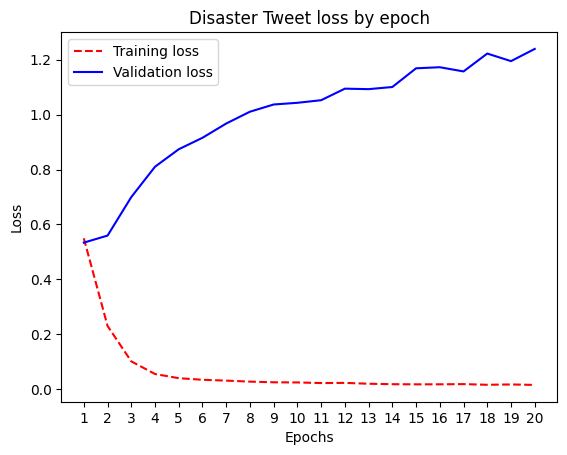

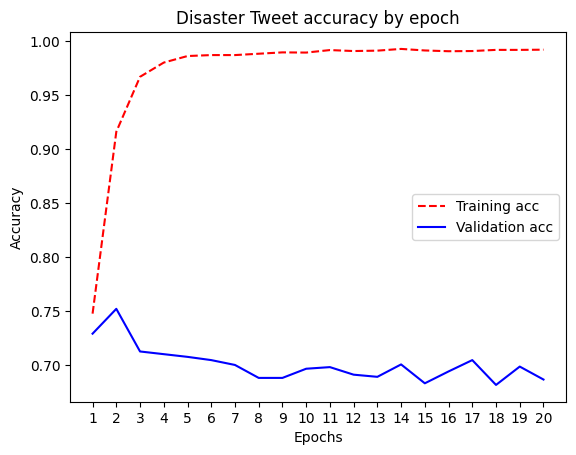

In [ ]:
import matplotlib.pyplot as plt

# DOC: Plot the loss
loss_values = history.history["loss"]
val_loss_values = history.history["val_loss"]
epochs = range(1, len(loss_values) + 1)
plt.plot(epochs, loss_values, "r--", label="Training loss")
plt.plot(epochs, val_loss_values, "b", label="Validation loss")
plt.title("Disaster Tweet loss by epoch")
plt.xlabel("Epochs")
plt.xticks(epochs)
plt.ylabel("Loss")
plt.legend()
plt.show()

# Plot the accuracy
acc = history.history["accuracy"]
val_acc = history.history["val_accuracy"]
plt.plot(epochs, acc, "r--", label="Training acc")
plt.plot(epochs, val_acc, "b", label="Validation acc")
plt.title("Disaster Tweet accuracy by epoch")
plt.xlabel("Epochs")
plt.xticks(epochs)
plt.ylabel("Accuracy")
plt.legend()
plt.show()

In [ ]:
# Try a much simpler Feed-Forward neural network
import keras
from keras import layers
model2 = keras.Sequential(
    [
        keras.Input(shape=(df_bag_vector_train.shape[1],)),
        layers.Dense(100, activation="relu"),
        layers.Dense(1, activation="sigmoid")
    ]
)
model2.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

# split out a validation set
num_samples = 2000
val_tweets = df_bag_vector_train[:num_samples]
val_labels = df_bag_train['target'][:num_samples]
train_tweets = df_bag_vector_train[num_samples:]
train_labels = df_bag_train['target'][num_samples:]

history = model2.fit(
  train_tweets.toarray(),
  train_labels,
  epochs=10,
  batch_size=512,
  validation_data=(val_tweets.toarray(), val_labels)
)

In [ ]:
# Shuffled feed-forward neural network

# Re-create vectors in shuffled order
from scipy.sparse import csr_matrix, vstack
df_bag_shuffled = df_bag_train.sample(frac=1, random_state=1976).reset_index(drop=True)
rows = [csr_matrix(encode_row(row)) for _,row in df_bag_shuffled.iterrows()]
df_bag_shuffled_vectors = vstack(rows)

# Use model with same shape as the last one
model3 = keras.Sequential(
    [
        keras.Input(shape=(df_bag_shuffled_vectors.shape[1],)),
        layers.Dense(100, activation="relu"),
        layers.Dense(1, activation="sigmoid")
    ]
)
model3.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

# split out a validation set
num_samples = 2000
val_tweets = df_bag_shuffled_vectors[:num_samples]
val_labels = df_bag_shuffled['target'][:num_samples]
train_tweets = df_bag_shuffled_vectors[num_samples:]
train_labels = df_bag_shuffled['target'][num_samples:]

history = model3.fit(
  train_tweets.toarray(),
  train_labels,
  epochs=10,
  batch_size=512,
  validation_data=(val_tweets.toarray(), val_labels)
)

Epoch 1/10
11/11 ━━━━━━━━━━━━━━━━━━━━ 3s 190ms/step - accuracy: 0.7091 - loss: 0.6531 - val_accuracy: 0.7580 - val_loss: 0.6031
Epoch 2/10
11/11 ━━━━━━━━━━━━━━━━━━━━ 3s 244ms/step - accuracy: 0.8384 - loss: 0.5178 - val_accuracy: 0.7890 - val_loss: 0.5219
Epoch 3/10
11/11 ━━━━━━━━━━━━━━━━━━━━ 4s 158ms/step - accuracy: 0.8785 - loss: 0.4033 - val_accuracy: 0.8020 - val_loss: 0.4785
Epoch 4/10
11/11 ━━━━━━━━━━━━━━━━━━━━ 2s 147ms/step - accuracy: 0.9082 - loss: 0.3194 - val_accuracy: 0.8060 - val_loss: 0.4610
Epoch 5/10
11/11 ━━━━━━━━━━━━━━━━━━━━ 2s 155ms/step - accuracy: 0.9252 - loss: 0.2583 - val_accuracy: 0.7995 - val_loss: 0.4588
Epoch 6/10
11/11 ━━━━━━━━━━━━━━━━━━━━ 4s 266ms/step - accuracy: 0.9398 - loss: 0.2132 - val_accuracy: 0.7955 - val_loss: 0.4626
Epoch 7/10
11/11 ━━━━━━━━━━━━━━━━━━━━ 2s 170ms/step - accuracy: 0.9517 - loss: 0.1778 - val_accuracy: 0.7960 - val_loss: 0.4707
Epoch 8/10
11/11 ━━━━━━━━━━━━━━━━━━━━ 2s 146ms/step - accuracy: 0.9612 - loss: 0.1506 - val_accuracy: 0.

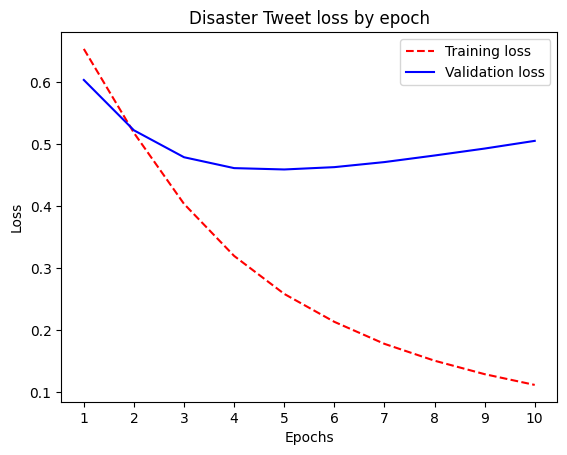

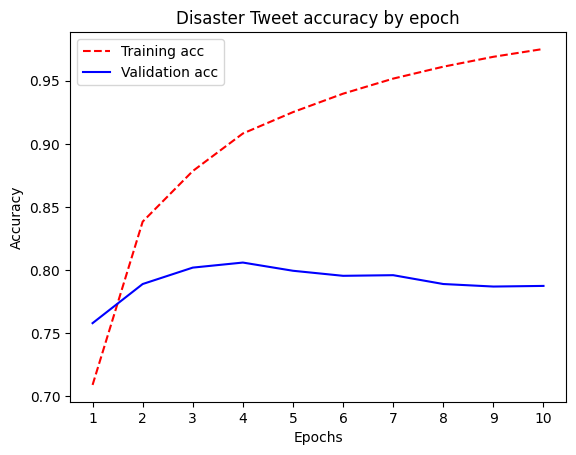

In [ ]:
import matplotlib.pyplot as plt

# Plot the loss
loss_values = history.history["loss"]
val_loss_values = history.history["val_loss"]
epochs = range(1, len(loss_values) + 1)
plt.plot(epochs, loss_values, "r--", label="Training loss")
plt.plot(epochs, val_loss_values, "b", label="Validation loss")
plt.title("Disaster Tweet loss by epoch")
plt.xlabel("Epochs")
plt.xticks(epochs)
plt.ylabel("Loss")
plt.legend()
plt.show()

# Plot the accuracy
acc = history.history["accuracy"]
val_acc = history.history["val_accuracy"]
plt.plot(epochs, acc, "r--", label="Training acc")
plt.plot(epochs, val_acc, "b", label="Validation acc")
plt.title("Disaster Tweet accuracy by epoch")
plt.xlabel("Epochs")
plt.xticks(epochs)
plt.ylabel("Accuracy")
plt.legend()
plt.show()

In [ ]:
# Encode the rows as a variable-length vector of tokens
TWEET_START = len(word_to_code_dict)+1
TWEET_END = len(word_to_code_dict)+2

def encode_row_positional(row):
  encoded = []
  if isinstance(row['keyword'], str):
    encoded.append(encode_word(row['keyword']))
  if isinstance(row['location'], str):
    for word in row['location'].split():
      encoded.append(encode_word(word))
  encoded.append(TWEET_START)
  for word in row['text'].split():
    encoded.append(encode_word(word))
  encoded.append(TWEET_END)
  return encoded

# Shuffle, pad with zeros, and encode into new dataframe
df_rnn_train = df_train.sample(frac=1, random_state=1976).reset_index(drop=True)
tweet_vectors = [encode_row_positional(row) for _,row in df_rnn_train.iterrows()]
max_length = max(len(t) for t in tweet_vectors)
tweet_vectors = [t + [0] * (max_length - len(t)) for t in tweet_vectors]
df_rnn_vector_train = pd.DataFrame(tweet_vectors)
print(df_rnn_vector_train.shape)

(7613, 37)


In [ ]:
# Build and train a Recurrent Neural Network with variable-length inputs
import keras
from keras import layers

# split out a validation set
num_samples = 2000
val_tweets = df_rnn_vector_train[:num_samples]
val_labels = df_rnn_train['target'][:num_samples]
train_tweets = df_rnn_vector_train[num_samples:]
train_labels = df_rnn_train['target'][num_samples:]

# build the model
inputs = keras.Input(shape=(None,))
rnn = layers.Embedding(input_dim=max(max(tweet_vectors))+1, output_dim=144, mask_zero=True)(inputs)
rnn = layers.LSTM(12, recurrent_dropout=0.25)(rnn)
rnn = layers.Dropout(0.5)(rnn)
outputs = layers.Dense(1, activation="sigmoid")(rnn)
rnn_model = keras.Model(inputs, outputs)

rnn_model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

# fit the model
history = rnn_model.fit(
    train_tweets,
    train_labels,
    epochs=10,
    batch_size=256,
    validation_data=(val_tweets, val_labels),
    callbacks=[
        keras.callbacks.ModelCheckpoint("rnn_tweet.keras", save_best_only=True)
    ]
)


Epoch 1/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 7s 185ms/step - accuracy: 0.5860 - loss: 0.6754 - val_accuracy: 0.6155 - val_loss: 0.6507
Epoch 2/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 4s 166ms/step - accuracy: 0.7162 - loss: 0.5966 - val_accuracy: 0.7590 - val_loss: 0.5523
Epoch 3/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 5s 207ms/step - accuracy: 0.8352 - loss: 0.4482 - val_accuracy: 0.7930 - val_loss: 0.4725
Epoch 4/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 4s 160ms/step - accuracy: 0.8968 - loss: 0.3099 - val_accuracy: 0.7865 - val_loss: 0.4930
Epoch 5/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 3s 154ms/step - accuracy: 0.9384 - loss: 0.2223 - val_accuracy: 0.7830 - val_loss: 0.5470
Epoch 6/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 4s 203ms/step - accuracy: 0.9633 - loss: 0.1490 - val_accuracy: 0.7750 - val_loss: 0.6212
Epoch 7/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 3s 159ms/step - accuracy: 0.9717 - loss: 0.1184 - val_accuracy: 0.7670 - val_loss: 0.6831
Epoch 8/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 3s 154ms/step - accuracy: 0.9786 - loss: 0.0951 - val_accuracy: 0.

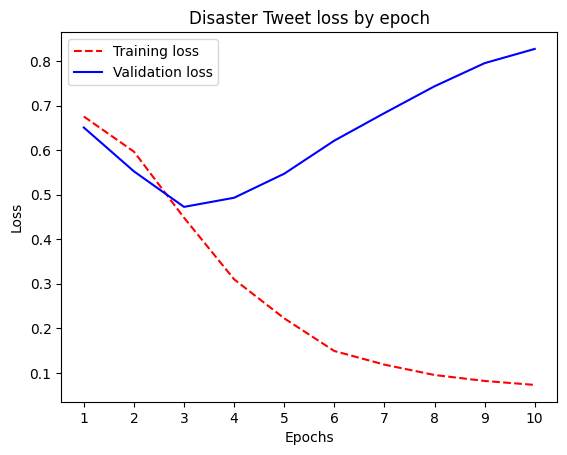

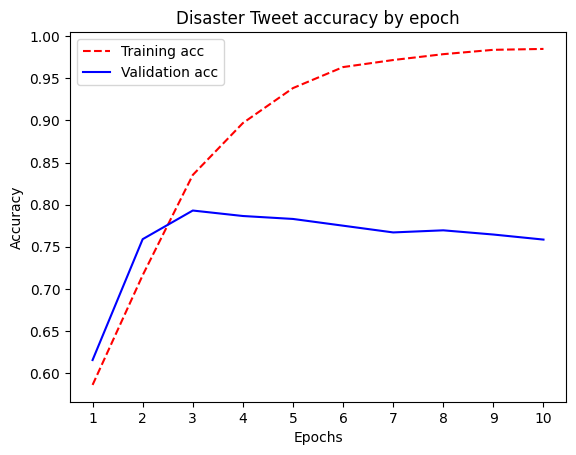

In [ ]:
import matplotlib.pyplot as plt

# Plot the loss
loss_values = history.history["loss"]
val_loss_values = history.history["val_loss"]
epochs = range(1, len(loss_values) + 1)
plt.plot(epochs, loss_values, "r--", label="Training loss")
plt.plot(epochs, val_loss_values, "b", label="Validation loss")
plt.title("Disaster Tweet loss by epoch")
plt.xlabel("Epochs")
plt.xticks(epochs)
plt.ylabel("Loss")
plt.legend()
plt.show()

# Plot the accuracy
acc = history.history["accuracy"]
val_acc = history.history["val_accuracy"]
plt.plot(epochs, acc, "r--", label="Training acc")
plt.plot(epochs, val_acc, "b", label="Validation acc")
plt.title("Disaster Tweet accuracy by epoch")
plt.xlabel("Epochs")
plt.xticks(epochs)
plt.ylabel("Accuracy")
plt.legend()
plt.show()

In [ ]:
!pip install gensim
import gensim.downloader as gensim
glove_embedding = gensim.load("glove-wiki-gigaword-100")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 68.0 MB/s eta 0:00:00
[==================================================] 100.0% 128.1/128.1MB downloaded


In [ ]:
import re

# Encode the rows as a variable-length vector of Gensim vectors
UNKNOWN = np.array([0.0]*100)

def encode_word_gensim(word):
  word = sanitize_word(word)
  if word in glove_embedding:
    return glove_embedding[word]
  strip_non_alpha = re.sub(r"[^A-Za-z]", '', word)
  if strip_non_alpha in glove_embedding:
    return glove_embedding[strip_non_alpha]
  else:
    return UNKNOWN

embeddable = 0
for w in word_to_code_dict.keys():
  if not np.array_equal(encode_word_gensim(w),UNKNOWN):
    embeddable += 1
print(f"{embeddable} of {len(word_to_code_dict)} words in dictionary are embeddable in Gensim")

15968 of 19676 words in dictionary are embeddable in Gensim


In [ ]:
TWEET_START = np.array([0.0]*99 + [1.0])
TWEET_END = np.array([0.0]*99 + [2.0])

def encode_row_gensim(row):
  encoded = []
  if isinstance(row['keyword'], str):
    encoded.append(encode_word_gensim(row['keyword']))
  if isinstance(row['location'], str):
    for word in row['location'].split():
      encoded.append(encode_word_gensim(word))
  encoded.append(TWEET_START)
  for word in row['text'].split():
    encoded.append(encode_word_gensim(word))
  encoded.append(TWEET_END)
  return encoded

# Shuffle, pad with UNKNOWN, and encode into new dataframe
df_gensim_train = df_train.sample(frac=1, random_state=1976).reset_index(drop=True)
tweet_gensim_vectors = [encode_row_gensim(row) for _,row in df_gensim_train.iterrows()]
max_length = max(len(t) for t in tweet_gensim_vectors)
tweet_gensim_vectors = np.array([np.array(t + [UNKNOWN] * (max_length - len(t))) for t in tweet_gensim_vectors])
print(tweet_gensim_vectors.shape)

(7613, 37, 100)


In [106]:
# Build and train a Convolutional Neural Network with pre-embedded inputs
import keras
from keras import layers

# split out a validation set
num_samples = 2000
val_tweets = tweet_gensim_vectors[:num_samples]
val_labels = df_gensim_train['target'][:num_samples]
train_tweets = tweet_gensim_vectors[num_samples:]
train_labels = df_gensim_train['target'][num_samples:]

# build the model
inputs = keras.Input(shape=(None, 100))
cnn = layers.Conv1D(filters=50, kernel_size=3, activation="relu", padding="same")(inputs)
cnn = layers.Dropout(0.5)(cnn)
cnn = layers.MaxPooling1D(2)(cnn)
cnn = layers.Conv1D(filters=20, kernel_size=3, activation="relu", padding="same")(cnn)
cnn = layers.MaxPooling1D(2)(cnn)
cnn = layers.Conv1D(filters=8, kernel_size=3, activation="relu", padding="same")(cnn)
cnn = layers.GlobalAveragePooling1D()(cnn)
outputs = layers.Dense(1, activation="sigmoid")(cnn)
cnn_model = keras.Model(inputs, outputs)

cnn_model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

# fit the model
history = cnn_model.fit(
    train_tweets,
    train_labels,
    epochs=20,
    batch_size=256,
    validation_data=(val_tweets, val_labels),
    callbacks=[
        keras.callbacks.ModelCheckpoint("rnn_tweet.keras", save_best_only=True)
    ]
)


Epoch 1/30
22/22 ━━━━━━━━━━━━━━━━━━━━ 7s 134ms/step - accuracy: 0.6431 - loss: 0.6472 - val_accuracy: 0.7290 - val_loss: 0.5910
Epoch 2/30
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.7559 - loss: 0.5290 - val_accuracy: 0.7665 - val_loss: 0.5085
Epoch 3/30
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.7798 - loss: 0.4875 - val_accuracy: 0.7970 - val_loss: 0.4749
Epoch 4/30
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.7930 - loss: 0.4598 - val_accuracy: 0.8010 - val_loss: 0.4623
Epoch 5/30
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.8005 - loss: 0.4504 - val_accuracy: 0.8045 - val_loss: 0.4558
Epoch 6/30
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.8033 - loss: 0.4360 - val_accuracy: 0.8010 - val_loss: 0.4507
Epoch 7/30
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.8129 - loss: 0.4276 - val_accuracy: 0.7965 - val_loss: 0.4531
Epoch 8/30
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.8135 - loss: 0.4228 - val_accuracy: 0.7985 - 

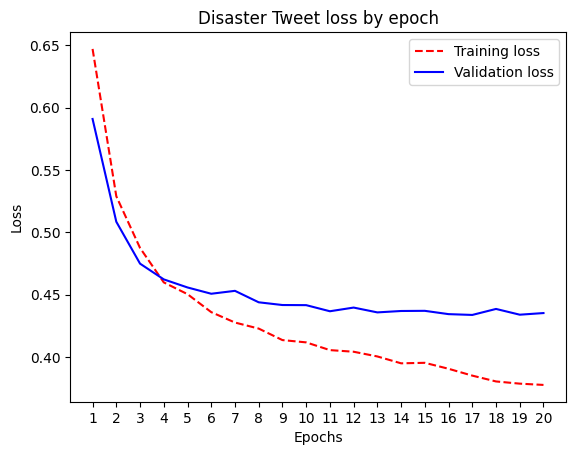

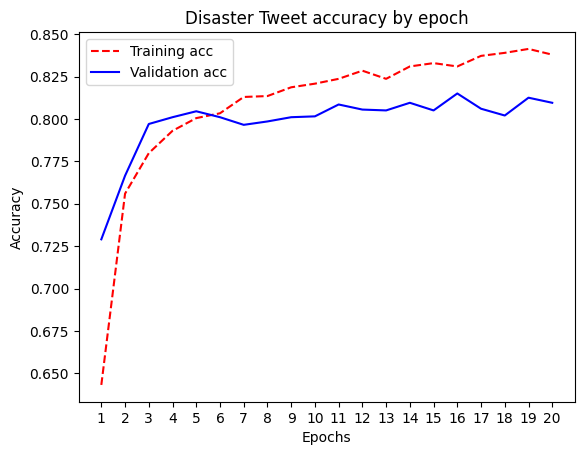

In [108]:
import matplotlib.pyplot as plt

# Plot the loss
loss_values = history.history["loss"]
val_loss_values = history.history["val_loss"]
epochs = range(1, len(loss_values) + 1)
plt.plot(epochs, loss_values, "r--", label="Training loss")
plt.plot(epochs, val_loss_values, "b", label="Validation loss")
plt.title("Disaster Tweet loss by epoch")
plt.xlabel("Epochs")
plt.xticks(epochs)
plt.ylabel("Loss")
plt.legend()
plt.show()

# Plot the accuracy
acc = history.history["accuracy"]
val_acc = history.history["val_accuracy"]
plt.plot(epochs, acc, "r--", label="Training acc")
plt.plot(epochs, val_acc, "b", label="Validation acc")
plt.title("Disaster Tweet accuracy by epoch")
plt.xlabel("Epochs")
plt.xticks(epochs)
plt.ylabel("Accuracy")
plt.legend()
plt.show()